In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("tickets_unificados_eda.csv",
                 sep="|")

In [7]:
df.head()

,ticket_ficticio,fecha_compra,cliente_ficticio,correo_ficticio,telefono_ficticio,direccion_ficticia,producto,categoria,cantidad_entregada,precio_total_eur,precio_unitario_eur,coste_servicio_eur,total_ticket_eur,kcal_100g,proteinas_g_100g,grasas_g_100g,fibra_g_100g,carbohidratos_g_100g,origen_macros,producto_categoria
0,FIC-2026-001,2026-02-28,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Crackers con sal Hacendado,NaN,1.0,"1,85","1,85","8,20","189,66",440.0,"9,0","13,0","3,0","70,0",estimacion_generica,NaN
1,FIC-2026-001,2026-02-28,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Pan de hamburguesa Brioche Hacendado,Cereales y derivados,1.0,"1,10","1,10","8,20","189,66",300.0,"9,0","9,0","2,5","48,0",estimacion_generica,Pan de hamburguesa Brioche Hacendado · Cereale...
2,FIC-2026-001,2026-02-28,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Salsa de Soja Hacendado,"Aceites, salsas y condimentos",1.0,"1,30","1,30","8,20","189,66",53.0,"8,0","0,0","0,0","5,0",estimacion_generica,"Salsa de Soja Hacendado · Aceites, salsas y co..."
3,FIC-2026-001,2026-02-28,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Pan de fibra y sésamo Hacendado,Cereales y derivados,1.0,"1,13","1,13","8,20","189,66",247.0,"9,0","3,4","6,9","45,0",estimacion_generica,Pan de fibra y sésamo Hacendado · Cereales y d...
4,FIC-2026-001,2026-02-28,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Suavizante ropa Azul Bosque Verde concentrado,No alimentario,1.0,"1,80","1,80","8,20","189,66",NaN,NaN,NaN,NaN,NaN,no_aplica,Suavizante ropa Azul Bosque Verde concentrado ...


In [10]:
num_columns = len(df.columns.tolist())
num_columns

20

In [11]:
df.columns.tolist()

['ticket_ficticio',
 'fecha_compra',
 'cliente_ficticio',
 'correo_ficticio',
 'telefono_ficticio',
 'direccion_ficticia',
 'producto',
 'categoria',
 'cantidad_entregada',
 'precio_total_eur',
 'precio_unitario_eur',
 'coste_servicio_eur',
 'total_ticket_eur',
 'kcal_100g',
 'proteinas_g_100g',
 'grasas_g_100g',
 'fibra_g_100g',
 'carbohidratos_g_100g',
 'origen_macros',
 'producto_categoria']

In [13]:
!pip install missingno

<Axes: >

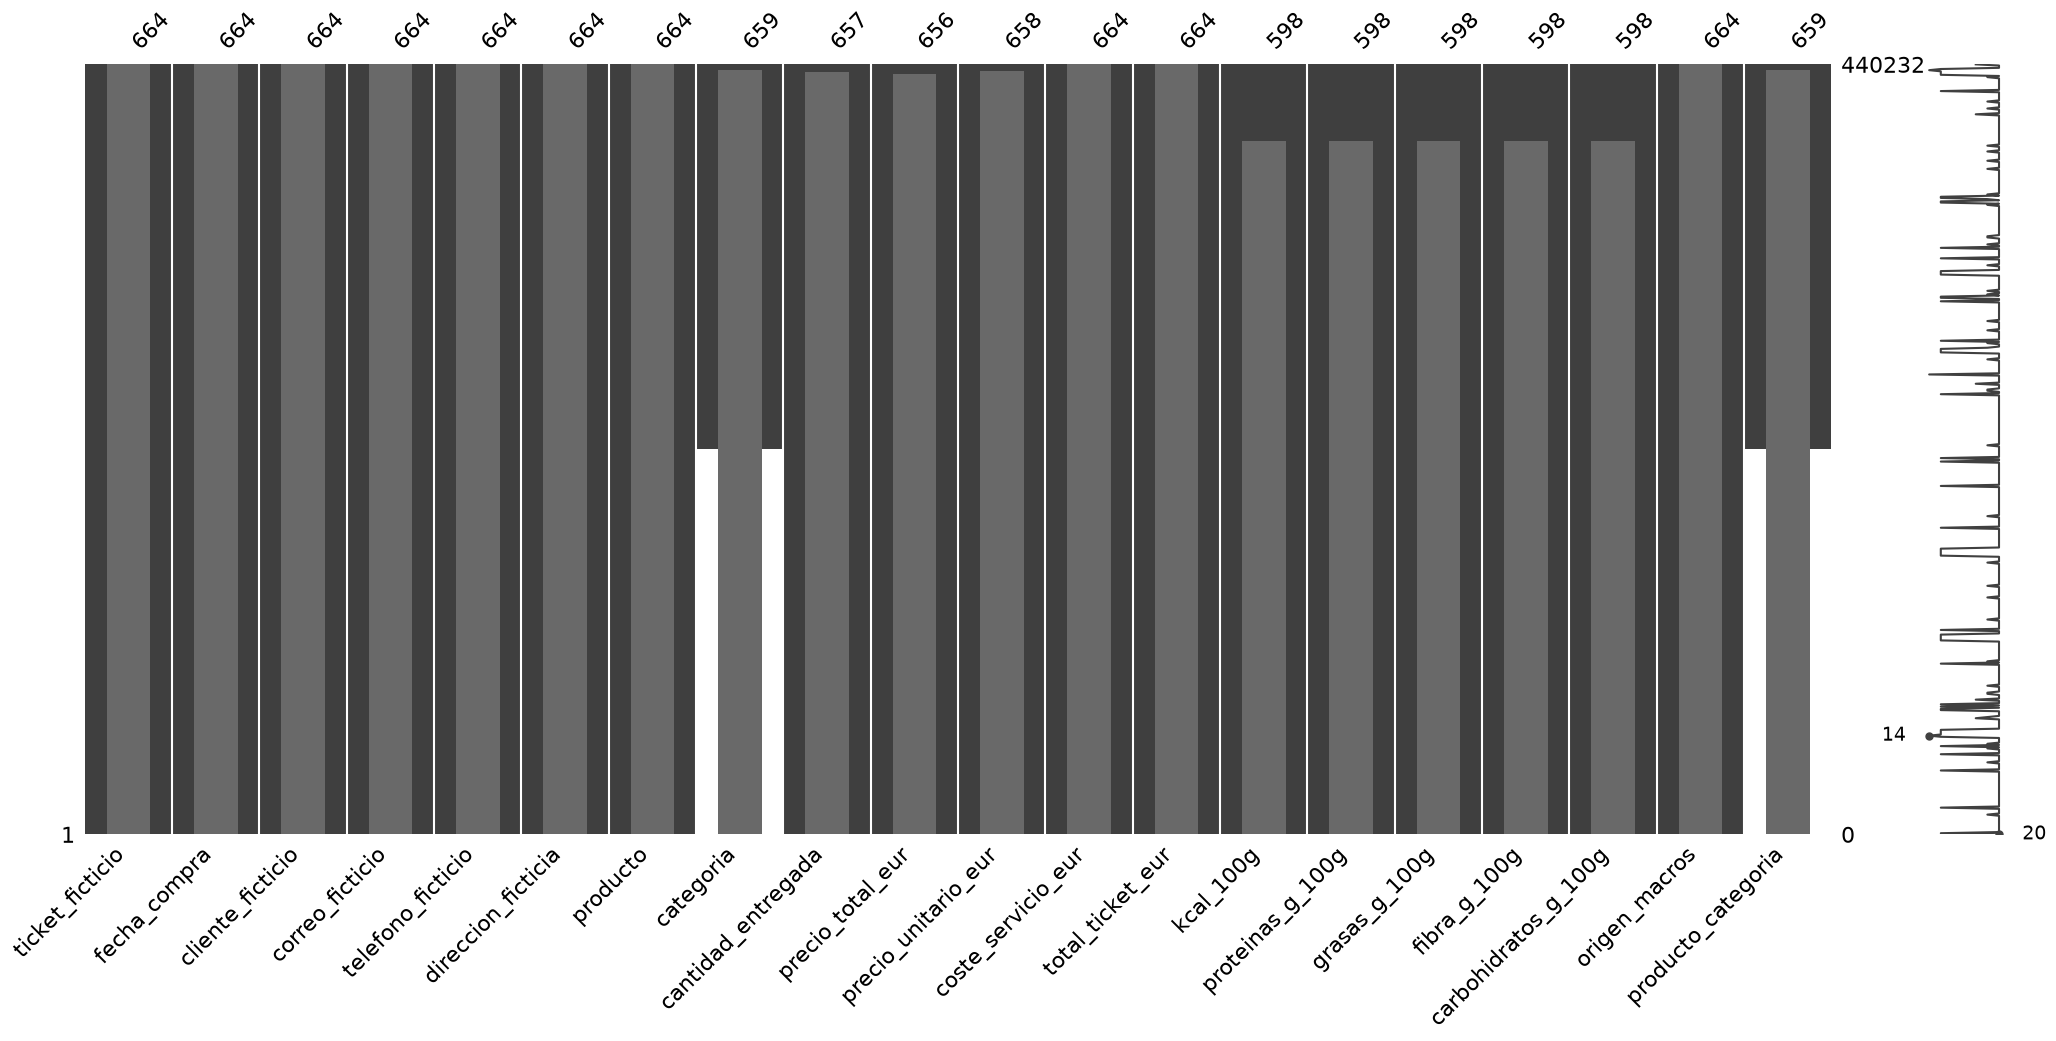

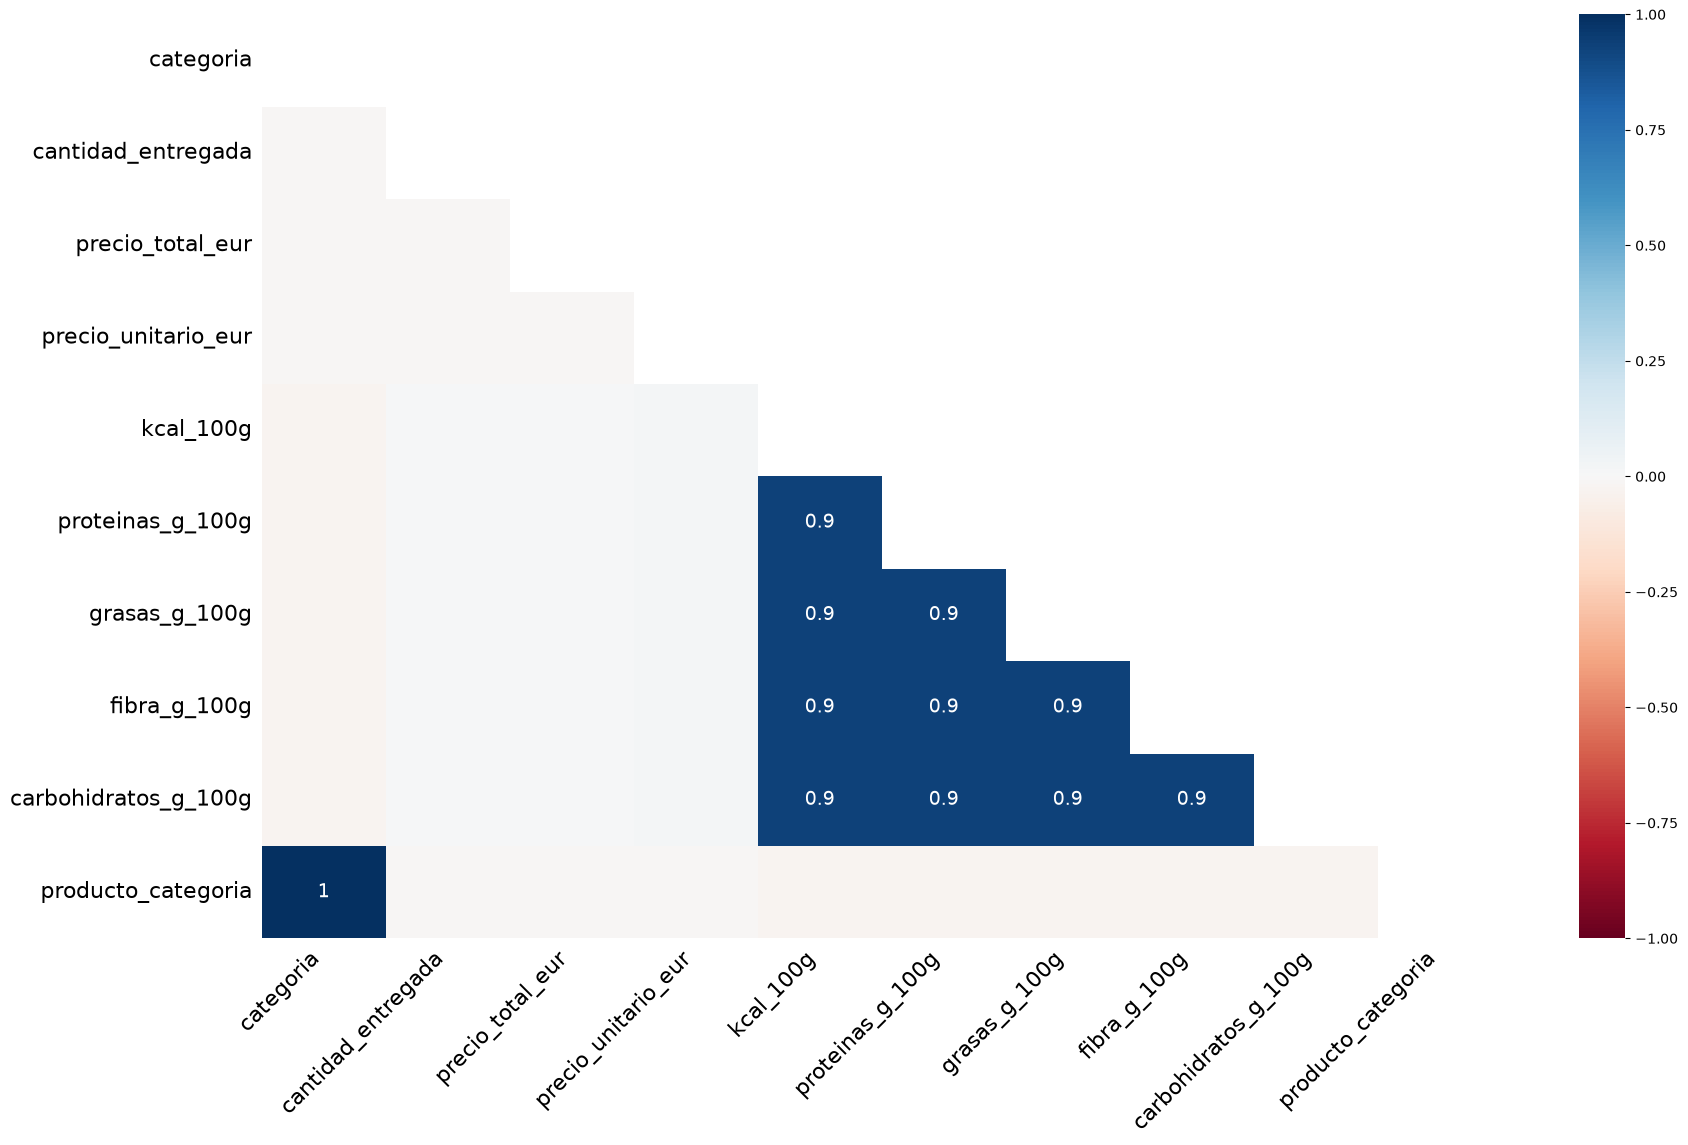

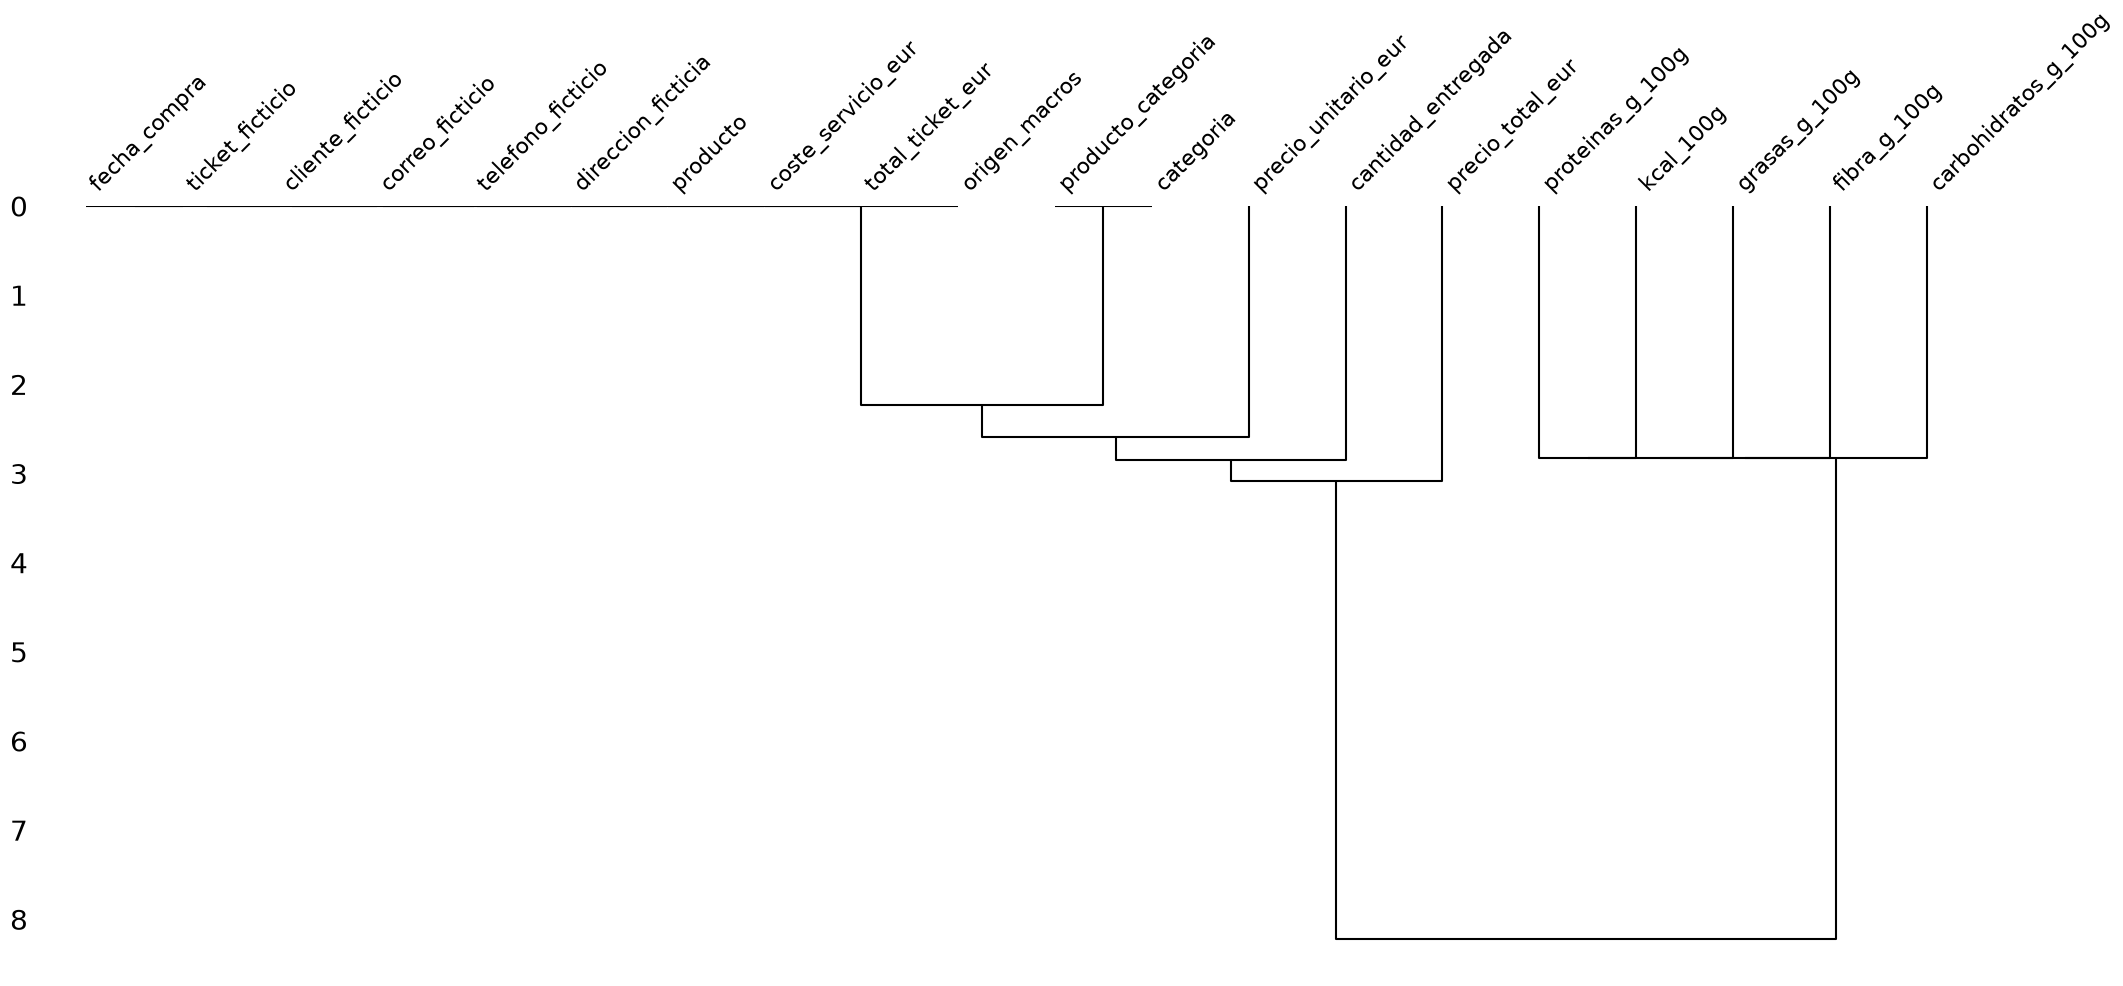

In [14]:
import missingno as msno

# 1. Matriz de nulidad: Muestra los missings como líneas blancas dentro de bloques grises
# Ideal para ver patrones geográficos, temporales o secuenciales en las filas
msno.matrix(df)

# 2. Gráfico de barras: Indica el conteo o porcentaje de datos completos por columna
msno.bar(df)

# 3. Mapa de calor (Heatmap): Muestra la correlación de nulidad entre variables 
# (por ejemplo, si cuando falta la variable A, siempre suele faltar la variable B)
msno.heatmap(df)

# 4. Dendrograma: Agrupa las variables mediante clústeres según la similitud de sus faltantes
msno.dendrogram(df)


In [23]:
df.shape

(664, 20)

In [24]:
df.isnull().sum()

ticket_ficticio          0
fecha_compra             0
cliente_ficticio         0
correo_ficticio          0
telefono_ficticio        0
direccion_ficticia       0
producto                 0
categoria                5
cantidad_entregada       7
precio_total_eur         8
precio_unitario_eur      6
coste_servicio_eur       0
total_ticket_eur         0
kcal_100g               66
proteinas_g_100g        66
grasas_g_100g           66
fibra_g_100g            66
carbohidratos_g_100g    66
origen_macros            0
producto_categoria       5
dtype: int64

<Axes: >

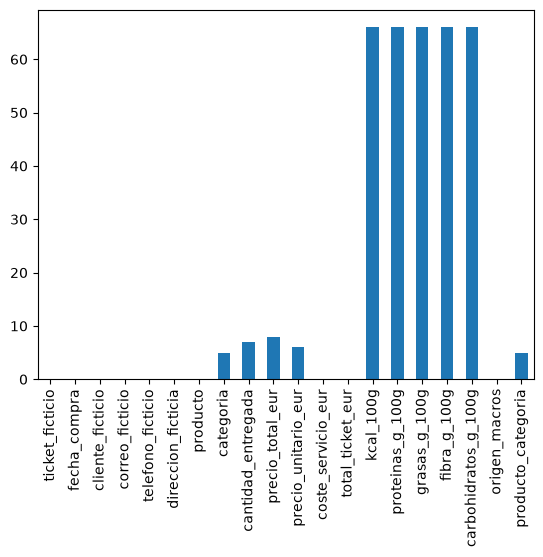

In [25]:
df.isnull().sum().plot(kind="bar")

In [33]:
df.fecha_compra.value_counts()

fecha_compra
2026-09-19    95
2026-07-23    91
2026-04-24    83
2026-05-27    79
2026-06-24    79
2026-08-21    78
2026-02-28    77
2026-03-26    76
26/03/2026     2
28/02/2026     1
27/05/2026     1
23/07/2026     1
21/08/2026     1
Name: count, dtype: int64

In [34]:
import pandas as pd

# 1. Convertir la columna al tipo datetime unificado usando format='mixed'
df['fecha_compra'] = pd.to_datetime(df['fecha_compra'], format='mixed')

# 2. Volver a ejecutar el conteo para ver los resultados agrupados correctamente
print(df['fecha_compra'].value_counts())


fecha_compra
2026-09-19    95
2026-07-23    92
2026-04-24    83
2026-05-27    80
2026-06-24    79
2026-08-21    79
2026-02-28    78
2026-03-26    78
Name: count, dtype: int64


In [36]:
df['fecha_compra'].value_counts().sort_index()

fecha_compra
2026-02-28    78
2026-03-26    78
2026-04-24    83
2026-05-27    80
2026-06-24    79
2026-07-23    92
2026-08-21    79
2026-09-19    95
Name: count, dtype: int64

<Axes: xlabel='fecha_compra'>

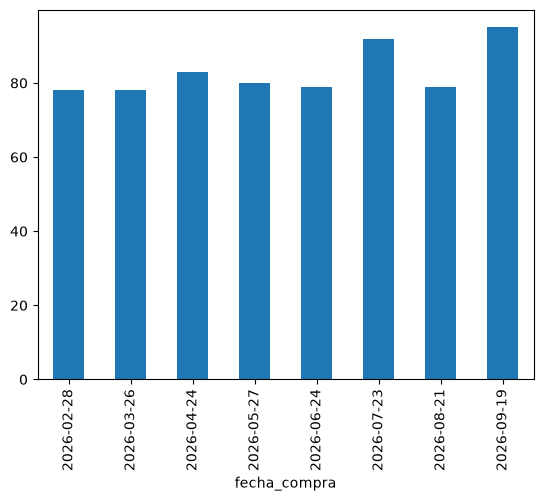

In [40]:
compra_fechas = df['fecha_compra'].value_counts().sort_index()
compra_fechas.index = compra_fechas.index.strftime('%Y-%m-%d')
compra_fechas.plot(kind="bar")

In [41]:
df.columns

Index(['ticket_ficticio', 'fecha_compra', 'cliente_ficticio',
       'correo_ficticio', 'telefono_ficticio', 'direccion_ficticia',
       'producto', 'categoria', 'cantidad_entregada', 'precio_total_eur',
       'precio_unitario_eur', 'coste_servicio_eur', 'total_ticket_eur',
       'kcal_100g', 'proteinas_g_100g', 'grasas_g_100g', 'fibra_g_100g',
       'carbohidratos_g_100g', 'origen_macros', 'producto_categoria'],
      dtype='str')

In [45]:
tickets_precio = df.total_ticket_eur.unique().tolist()

In [49]:
facturas = [float(ticket.replace(",", ".")) for ticket in tickets_precio]
facturas

[189.66, 198.04, 216.41, 223.44, 214.5, 243.51, 218.18, 258.54]

In [53]:
import numpy as np
np.mean(facturas), np.sum(facturas), np.min(facturas), np.max(facturas)

(np.float64(220.285),
 np.float64(1762.28),
 np.float64(189.66),
 np.float64(258.54))

In [54]:
len(facturas)

8

In [55]:
df.columns

Index(['ticket_ficticio', 'fecha_compra', 'cliente_ficticio',
       'correo_ficticio', 'telefono_ficticio', 'direccion_ficticia',
       'producto', 'categoria', 'cantidad_entregada', 'precio_total_eur',
       'precio_unitario_eur', 'coste_servicio_eur', 'total_ticket_eur',
       'kcal_100g', 'proteinas_g_100g', 'grasas_g_100g', 'fibra_g_100g',
       'carbohidratos_g_100g', 'origen_macros', 'producto_categoria'],
      dtype='str')

In [62]:
df.producto.value_counts()[df.producto.value_counts()==8]

producto
Pan de fibra y sésamo Hacendado              8
Papel higiénico húmedo WC Bosque Verde       8
Nachos Hacendado                             8
Huevos                                       8
Tofu firme Hacendado                         8
Leche semidesnatada sin lactosa Hacendado    8
Pimientos semipicantes                       8
Moras                                        8
Name: count, dtype: int64

In [63]:
df.producto.value_counts()[df.producto.value_counts()==5]

producto
Pimientos del piquillo enteros Hacendado extra           5
Edamame soja verde Hacendado ultracongelada              5
Ajo troceado Hacendado ultracongelado                    5
Queso lonchas cheddar de vaca Hacendado                  5
Tomate frito Hacendado                                   5
Atún claro al natural Hacendado                          5
Manzana Golden                                           5
Pimientos del piquillo en tiras con ajo Hacendado        5
Pechuga de pollo braseada extrafino Hacendado lonchas    5
Berenjena                                                5
Name: count, dtype: int64

<Axes: xlabel='producto'>

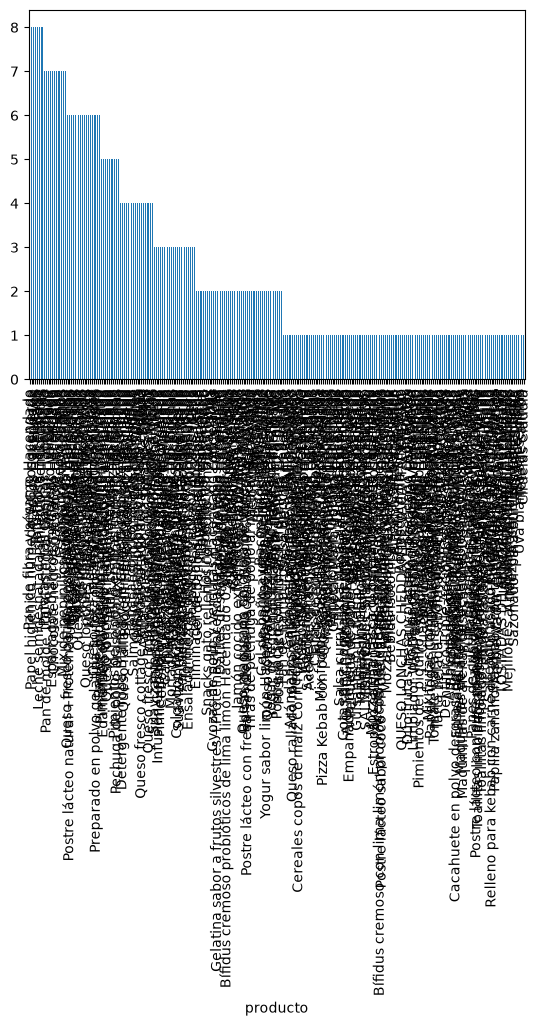

In [60]:
df.producto.value_counts().plot(kind="bar")

In [59]:
df.producto.nunique()

262

In [65]:
df.duplicated().sum()

np.int64(5)

In [68]:
df[df.duplicated()]

,ticket_ficticio,fecha_compra,cliente_ficticio,correo_ficticio,telefono_ficticio,direccion_ficticia,producto,categoria,cantidad_entregada,precio_total_eur,precio_unitario_eur,coste_servicio_eur,total_ticket_eur,kcal_100g,proteinas_g_100g,grasas_g_100g,fibra_g_100g,carbohidratos_g_100g,origen_macros,producto_categoria
659,FIC-2026-001,2026-02-28,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Gyozas de pollo y verduras Hacendado congeladas,Elaborados y aperitivos,1.0,"2,15","2,15","8,20","189,66",180.0,"8,0","6,0","2,0","24,0",estimacion_generica,Gyozas de pollo y verduras Hacendado congelada...
660,FIC-2026-008,2026-09-19,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Berenjena,Frutas y verduras,4.0,"3,92","0,98","8,20","258,54",24.0,"1,0","0,2","3,0","5,5",estimacion_generica,Berenjena · Frutas y verduras
661,FIC-2026-002,2026-03-26,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Pan de molde 100% integral familiar Hacendado,Cereales y derivados,1.0,"1,18","1,18","8,20","198,04",247.0,"9,0","3,4","6,9","45,0",estimacion_generica,Pan de molde 100% integral familiar Hacendado ...
662,FIC-2026-008,2026-09-19,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Gasas para bebé no tejidas Deliplus,No alimentario,1.0,"1,97","1,97","8,20","258,54",NaN,NaN,NaN,NaN,NaN,no_aplica,Gasas para bebé no tejidas Deliplus · No alime...
663,FIC-2026-004,2026-05-27,Elena Martín Robles,elena.martin@example.org,0,"Calle Ficticia 17, 3.º B, 28013 Madrid",Mini taquitos de jamón Incarlopsa,"Carnes, pescados y huevos",1.0,"2,65","2,65","8,20","223,44",107.0,"18,4","3,6","0,0","1,5",estimacion_generica,"Mini taquitos de jamón Incarlopsa · Carnes, pe..."


In [69]:
df.columns

Index(['ticket_ficticio', 'fecha_compra', 'cliente_ficticio',
       'correo_ficticio', 'telefono_ficticio', 'direccion_ficticia',
       'producto', 'categoria', 'cantidad_entregada', 'precio_total_eur',
       'precio_unitario_eur', 'coste_servicio_eur', 'total_ticket_eur',
       'kcal_100g', 'proteinas_g_100g', 'grasas_g_100g', 'fibra_g_100g',
       'carbohidratos_g_100g', 'origen_macros', 'producto_categoria'],
      dtype='str')

In [73]:
df = df.drop(columns=['ticket_ficticio','cliente_ficticio',
       'correo_ficticio', 'telefono_ficticio', 'direccion_ficticia'])

In [76]:
df["producto"][df.categoria == "Condimentos"]

110    Hoja de laurel Hacendado
413     Ajo granulado Hacendado
Name: producto, dtype: str

In [79]:
df.categoria.unique()

<ArrowStringArray>
[                             nan,           'Cereales y derivados',
  'Aceites, salsas y condimentos',                 'No alimentario',
                        'Bebidas',        'Elaborados y aperitivos',
      'Carnes, pescados y huevos',            'Lácteos y derivados',
                      'Legumbres',              'Frutas y verduras',
        'frutos secos y semillas',        'Frutos secos y semillas',
 'Bebidas y preparados vegetales',                    'Condimentos',
              'frutas y verduras',            'lácteos y derivados']
Length: 16, dtype: str

In [80]:
df["producto"][df.categoria == "Bebidas"].unique()

<ArrowStringArray>
['Infusión Cúrcuma Hacendado con manzana y canela',
                         'Infusión Tila Hacendado',
                     'INFUSIÓN JENGIBRE HACENDADO',
          'Infusión Manzanilla con anís Hacendado',
                        'Licor crema Puente Pazos',
                        'Refresco lima limón 7 Up',
        'Bebida isotónica sabor cítrico Iso drink',
              'Agua mineral con gas grande Cortes',
                    '  Refresco  lima limón 7 Up ',
                  'Café soluble Classic Hacendado',
                     'Infusión Jengibre Hacendado']
Length: 11, dtype: str

In [81]:
df.columns

Index(['fecha_compra', 'producto', 'categoria', 'cantidad_entregada',
       'precio_total_eur', 'precio_unitario_eur', 'coste_servicio_eur',
       'total_ticket_eur', 'kcal_100g', 'proteinas_g_100g', 'grasas_g_100g',
       'fibra_g_100g', 'carbohidratos_g_100g', 'origen_macros',
       'producto_categoria'],
      dtype='str')

In [83]:
df = df.drop(columns=["producto_categoria"])

In [85]:
df.columns

Index(['fecha_compra', 'producto', 'categoria', 'cantidad_entregada',
       'precio_total_eur', 'precio_unitario_eur', 'coste_servicio_eur',
       'total_ticket_eur', 'kcal_100g', 'proteinas_g_100g', 'grasas_g_100g',
       'fibra_g_100g', 'carbohidratos_g_100g', 'origen_macros'],
      dtype='str')

In [87]:
df.origen_macros.unique()

<ArrowStringArray>
['estimacion_generica', 'no_aplica']
Length: 2, dtype: str

In [90]:
df[df.kcal_100g == df.kcal_100g.max()]

,fecha_compra,producto,categoria,cantidad_entregada,precio_total_eur,precio_unitario_eur,coste_servicio_eur,total_ticket_eur,kcal_100g,proteinas_g_100g,grasas_g_100g,fibra_g_100g,carbohidratos_g_100g,origen_macros
191,2026-04-24,Mini taquitos de jamón Incarlopsa,"Carnes, pescados y huevos",1.0,"2,65","2,65","8,20","216,41",1070.0,"18,4","3,6","0,0","1,5",estimacion_generica


In [91]:
df.dtypes

fecha_compra            datetime64[us]
producto                           str
categoria                          str
cantidad_entregada             float64
precio_total_eur                   str
precio_unitario_eur                str
coste_servicio_eur                 str
total_ticket_eur                   str
kcal_100g                      float64
proteinas_g_100g                   str
grasas_g_100g                      str
fibra_g_100g                       str
carbohidratos_g_100g               str
origen_macros                      str
dtype: object

In [92]:
df.columns

Index(['fecha_compra', 'producto', 'categoria', 'cantidad_entregada',
       'precio_total_eur', 'precio_unitario_eur', 'coste_servicio_eur',
       'total_ticket_eur', 'kcal_100g', 'proteinas_g_100g', 'grasas_g_100g',
       'fibra_g_100g', 'carbohidratos_g_100g', 'origen_macros'],
      dtype='str')

In [96]:
cols = ['precio_total_eur', 'precio_unitario_eur', 'coste_servicio_eur',
        'total_ticket_eur', 'proteinas_g_100g', 'grasas_g_100g',
        'fibra_g_100g', 'carbohidratos_g_100g']

df[cols] = (
    df[cols]
    .apply(lambda s: s.astype(str).str.replace(',', '.', regex=False))
    .apply(pd.to_numeric, errors='coerce')
)

In [98]:
df.dtypes

fecha_compra            datetime64[us]
producto                           str
categoria                          str
cantidad_entregada             float64
precio_total_eur               float64
precio_unitario_eur            float64
coste_servicio_eur             float64
total_ticket_eur               float64
kcal_100g                      float64
proteinas_g_100g               float64
grasas_g_100g                  float64
fibra_g_100g                   float64
carbohidratos_g_100g           float64
origen_macros                      str
dtype: object

<Axes: >

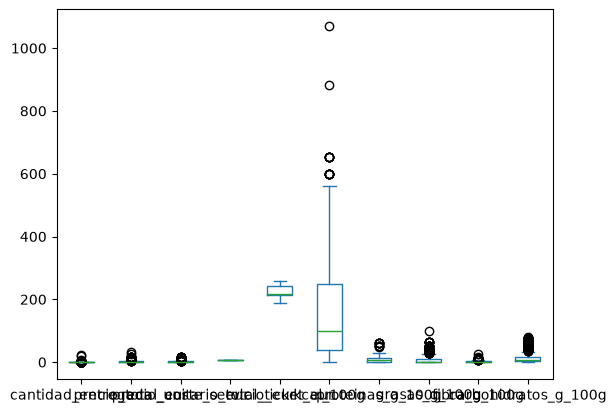

In [100]:
df.plot.box()

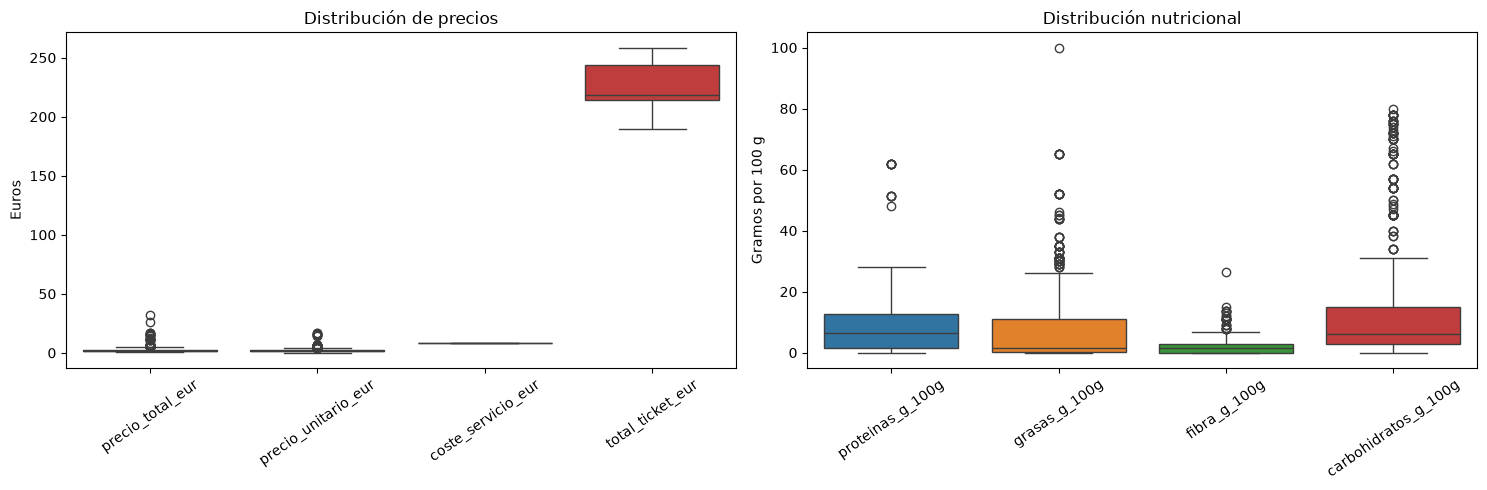

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

precios = [
    'precio_total_eur',
    'precio_unitario_eur',
    'coste_servicio_eur',
    'total_ticket_eur'
]

nutrientes = [
    'proteinas_g_100g',
    'grasas_g_100g',
    'fibra_g_100g',
    'carbohidratos_g_100g'
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df[precios], ax=axes[0])
axes[0].set_title('Distribución de precios')
axes[0].set_ylabel('Euros')
axes[0].tick_params(axis='x', rotation=35)

sns.boxplot(data=df[nutrientes], ax=axes[1])
axes[1].set_title('Distribución nutricional')
axes[1].set_ylabel('Gramos por 100 g')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

<Axes: xlabel='fecha_compra'>

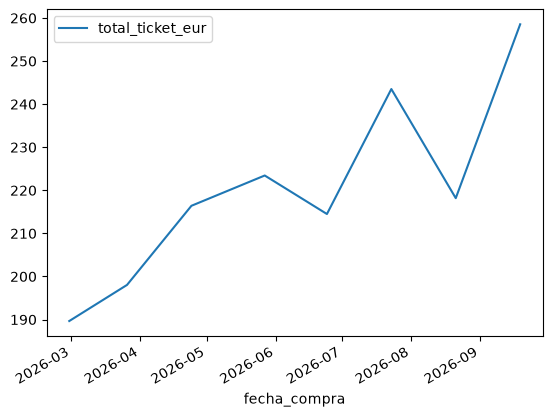

In [111]:
df[["fecha_compra","total_ticket_eur"]].groupby("fecha_compra").mean().plot()

In [113]:
df[df.precio_total_eur>20]

,fecha_compra,producto,categoria,cantidad_entregada,precio_total_eur,precio_unitario_eur,coste_servicio_eur,total_ticket_eur,kcal_100g,proteinas_g_100g,grasas_g_100g,fibra_g_100g,carbohidratos_g_100g,origen_macros
96,2026-03-26,Mini taquitos de jamón Incarlopsa,"Carnes, pescados y huevos",1.0,26.5,2.65,8.2,198.04,107.0,18.4,3.6,0.0,1.5,estimacion_generica
657,2026-09-19,Filete de salmón,"Carnes, pescados y huevos",2.0,31.9,15.95,8.2,258.54,208.0,20.4,13.4,0.0,0.0,estimacion_generica


In [114]:
df[df.precio_total_eur<0.2]

,fecha_compra,producto,categoria,cantidad_entregada,precio_total_eur,precio_unitario_eur,coste_servicio_eur,total_ticket_eur,kcal_100g,proteinas_g_100g,grasas_g_100g,fibra_g_100g,carbohidratos_g_100g,origen_macros
